# 라이브러리 임포트 및 글로벌 세팅

In [1]:
# %%
# =============================================================================
# [Cell 18a] (신규) 📈 Mac 한글 폰트 깨짐 해결
# =============================================================================
# (그래프를 그리기 전에 이 셀을 먼저 실행해주세요)

import matplotlib.pyplot as plt

# 1. Mac에서 한글을 지원하는 'AppleGothic' 폰트로 설정
plt.rcParams['font.family'] = 'AppleGothic'

# 2. 폰트 변경 시 마이너스('-') 기호 깨지는 현상 해결
# (유니코드 마이너스 대신 일반 하이픈을 사용하도록 설정)
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트(AppleGothic) 및 마이너스 기호 설정이 완료되었습니다.")
print("이제 [Cell 19]와 [Cell 20]을 다시 실행하면 글꼴이 정상적으로 표시됩니다.")

한글 폰트(AppleGothic) 및 마이너스 기호 설정이 완료되었습니다.
이제 [Cell 19]와 [Cell 20]을 다시 실행하면 글꼴이 정상적으로 표시됩니다.


In [18]:
# %%
# =============================================================================
# [Cell 1] 
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from pandas.tseries.offsets import BMonthEnd
from scipy.stats import zscore
from fredapi import Fred

# (경고 메시지 무시)
import warnings
warnings.filterwarnings('ignore')

# --- [0] 글로벌 세팅 ---

# 백테스트 기간
START_DATE = '2015-08-01'
END_DATE = '2025-11-28'  # <-- 이렇게 수정합니다.

# 사용 ETF 및 벤치마크
TICKERS = ['SHYG', 'IEF', 'SHY', 'TLT', 'AGG']
BENCHMARK = 'AGG'

# 거래 비용 (편도)
TRANSACTION_COSTS = {
    'SHYG': 0.003,  # 0.3%
    'IEF': 0.0015,  # 0.15%
    'SHY': 0.0015,
    'TLT': 0.0015,
    'AGG': 0.0015,
}

# 레짐별 타깃 포트폴리오 (섹션 5 기반)
# [수정안 3] 전반적으로 SHYG 비중을 대폭 상향 조정한 '초공격적' 안
# 목표: AGG의 크레딧 베타(0.26)를 초과하는 것
REGIME_ALLOCATIONS = {
    # 1: Very Risk-On (크레딧 위험 가장 낮음) -> SHYG 극대화 (Carry 극대화)
    1: {'SHYG': 0.85, 'IEF': 0.15}, 
    
    # 2: Risk-On (스프레드 축소 모멘텀) -> 모멘텀에 적극 편승
    2: {'SHYG': 0.60, 'IEF': 0.40}, 
    
    # 3: Risk-Off (스프레드 확대 모멘텀) -> 비중 축소, (수정안2의 25%보다 높게 유지)
    3: {'SHYG': 0.35, 'IEF': 0.65}, 
    
    # 4: Very Risk-Off (시장 공포) -> 공격적(Contrarian)으로 저가 매수 비중 유지
    4: {'SHYG': 0.15, 'IEF': 0.85}, 
}

# FRED API 키 (!!필수!!: 'YOUR_API_KEY_HERE'를 본인의 키로 변경)
FRED_API_KEY = 'f75d683dda2053416b64caae44e1bfb2' 

# 롤링 윈도우 설정
OAS_Z_WINDOW = 24  # 24개월 (모멘텀)
PPR_WINDOW = 60    # 60개월 (레벨)

print("셀 1: 기본 세팅 완료.")

셀 1: 기본 세팅 완료.


# 데이터 로딩

In [19]:
# %%
# =============================================================================
# [Cell 2] 
# =============================================================================

def load_data(tickers, start, end):
    """yfinance에서 수정종가(Adj Close) 데이터를 로드 (월말 기준)"""
    print("Step 1.a: yfinance 데이터 로딩 중...")
    try:
        data = yf.download(tickers, start=start, end=end)['Close']
        if isinstance(data.columns, str):
            data = data.to_frame(tickers[0])
        monthly_prices = data.resample('BM').last()
        monthly_returns = monthly_prices.pct_change().dropna()
        print("yfinance 데이터 로딩 및 월별 전처리 완료.")
        return monthly_prices, monthly_returns
    except Exception as e:
        print(f"yfinance 데이터 로드 오류: {e}")
        return None, None

def load_external_data(fred_api_key, series_id, end_date):
    """
    FRED API를 통해 OAS 데이터를 로드 (수정됨: 롤링 윈도우를 위해 넉넉하게 불러옴)
    """
    print(f"Step 1.b: FRED API에서 {series_id} 로딩 중...")
    try:
        fred = Fred(api_key=fred_api_key)
        
        # (!! 중요 !!)
        # 롤링 윈도우(60개월) 계산을 위해 백테스트 종료일 기준 15년 전 데이터부터 로드
        # (60개월 + 백테스트 기간 10년)
        fetch_start_date = (pd.to_datetime(end_date) - pd.DateOffset(years=15)).strftime('%Y-%m-%d')
        
        oas_series = fred.get_series(series_id, start_date=fetch_start_date, end_date=end_date)
        
        if oas_series.empty:
            print(f"오류: FRED에서 {series_id} 데이터를 가져오지 못했습니다.")
            return None

        # 월말(BM) 기준으로 리샘플링
        oas_series = oas_series.resample('BM').last().ffill()
        oas_series.name = 'OAS'
        
        print("OAS 데이터 로딩 및 월별 전처리 완료.")
        return oas_series
    
    except Exception as e:
        print(f"FRED API 오류: {e}")
        return None

print("셀 2: 데이터 로딩 함수 정의 완료.")

셀 2: 데이터 로딩 함수 정의 완료.


# 헬퍼 함수 정의 (성과분석 및 레짐)

In [20]:
# %%
# =============================================================================
# [Cell 3] 
# =============================================================================

# --- [2] 성과 지표 ---
def calculate_cagr(returns_series, periods_per_year=12):
    if len(returns_series) < 1: return np.nan
    total_return = (1 + returns_series).prod()
    num_years = len(returns_series) / periods_per_year
    return total_return ** (1 / num_years) - 1

def calculate_mdd(returns_series):
    cumulative_returns = (1 + returns_series).cumprod()
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns - peak) / peak
    return drawdown.min()

def calculate_sharpe_ratio(returns_series, risk_free_rate=0.0, periods_per_year=12):
    excess_returns = returns_series - (risk_free_rate / periods_per_year)
    mean_excess_return = excess_returns.mean()
    std_dev = excess_returns.std()
    if std_dev == 0: return np.nan
    return (mean_excess_return / std_dev) * np.sqrt(periods_per_year)

def calculate_turnover(weights_df):
    turnover = weights_df.diff().abs().sum(axis=1) / 2.0
    return turnover.mean()

def generate_performance_summary(returns_series, benchmark_returns):
    summary = {}
    summary['Strategy'] = {
        'CAGR': calculate_cagr(returns_series),
        'MDD': calculate_mdd(returns_series),
        'Sharpe Ratio': calculate_sharpe_ratio(returns_series)
    }
    summary['Benchmark (AGG)'] = {
        'CAGR': calculate_cagr(benchmark_returns),
        'MDD': calculate_mdd(benchmark_returns),
        'Sharpe Ratio': calculate_sharpe_ratio(benchmark_returns)
    }
    summary_df = pd.DataFrame(summary).T
    return summary_df.applymap(lambda x: f"{x:.2%}" if x > -1 else f"{x:.2f}")

# --- [3] Regime 분류 ---
# [Cell 3]의 calculate_regime_signals 함수만 이걸로 교체하세요.

def calculate_regime_signals(oas_series, shyg_price_series, oas_z_window=24, elp_window=12):
    """
    (수정됨)
    1. OAS 모멘텀 (OAS_Z) 계산
    2. SHYG 가격 기반 ELP_proxy (PPR로 사용) 계산
    """
    print(f"Step 3: 레짐 시그널 계산 중 (SHYG Price ELP_proxy {elp_window}M Window)...")
    
    # 1. OAS_Z (OAS 모멘텀)
    oas_z = oas_series.rolling(window=oas_z_window).apply(
        lambda x: (x[-1] - x.mean()) / x.std() if len(x) == oas_z_window else np.nan,
        raw=False
    )
    
    # 2. ELP_proxy (PPR 대체)
    # 1년간(12M) SHYG 가격의 백분위 순위 (낮을수록 0, 높을수록 1)
    # (사용자 요청: 1년치 가격의 백분위 순위)
    percentile_rank = shyg_price_series.rolling(window=elp_window).rank(pct=True)
    
    # ELP_proxy = 1 - PercentileRank
    # (값이 클수록 "가격이 싸다" -> 스트레스 높음)
    elp_proxy = 1.0 - percentile_rank

    # 'PPR'이라는 컬럼 이름으로 저장하여
    # downstream 함수(define_regime)와 호환되도록 함
    signals = pd.DataFrame({'OAS_Z': oas_z, 'PPR': elp_proxy}).dropna()
    
    print("레짐 시그널 (OAS_Z + ELP_proxy as PPR) 생성 완료.")
    return signals

def define_regime(row):
    ppr, oas_z = row['PPR'], row['OAS_Z']
    if ppr < 0.2: return 1 # ① Very Risk-On
    if ppr > 0.8: return 4 # ④ Very Risk-Off
    if 0.2 <= ppr <= 0.8 and oas_z < 0: return 2 # ② Risk-On
    if 0.2 <= ppr <= 0.8 and oas_z >= 0: return 3 # ③ Risk-Off
    return np.nan

def generate_regime_timeseries(signals):
    regime_series = signals.apply(define_regime, axis=1)
    regime_series.name = 'Regime'
    return regime_series

# --- [4] 전략 구성 ---
def get_target_weights(regime_series):
    print("Step 4: 타깃 비중 생성 중...")
    target_weights = pd.DataFrame(index=regime_series.index, columns=['SHYG', 'IEF'])
    for regime, alloc in REGIME_ALLOCATIONS.items():
        mask = (regime_series == regime)
        target_weights.loc[mask] = [alloc['SHYG'], alloc['IEF']]
    target_weights = target_weights.ffill().dropna()
    return target_weights

# --- [5] 백테스트 ---
def run_backtest(monthly_returns, target_weights, transaction_costs):
    print("Step 5: 백테스트 실행 중...")
    shifted_weights = target_weights.shift(1).dropna()
    common_index = monthly_returns.index.intersection(shifted_weights.index)
    returns = monthly_returns.loc[common_index]
    weights = shifted_weights.loc[common_index]
    
    gross_returns = (returns * weights).sum(axis=1)
    
    turnover_df = weights.diff().abs()
    cost_series = pd.Series(0.0, index=turnover_df.index)
    for asset in weights.columns:
        cost_series += turnover_df[asset] * transaction_costs[asset]
        
    net_returns = gross_returns - cost_series
    net_returns.name = 'Strategy'
    print("백테스트 완료.")
    return net_returns, weights, gross_returns

def analyze_stress_period(strategy_returns, benchmark_returns, start, end):
    stress_strategy = strategy_returns.loc[start:end]
    stress_bench = benchmark_returns.loc[start:end]
    summary = {
        'Strategy': {
            'Cumulative Return': (1 + stress_strategy).prod() - 1,
            'MDD': calculate_mdd(stress_strategy)
        },
        'Benchmark': {
            'Cumulative Return': (1 + stress_bench).prod() - 1,
            'MDD': calculate_mdd(stress_bench)
        }
    }
    return pd.DataFrame(summary).T.applymap(lambda x: f"{x:.2%}")

print("셀 3: 헬퍼 함수 정의 완료.")

셀 3: 헬퍼 함수 정의 완료.


In [21]:
# %%
# =============================================================================
# [Cell 3a] (신규) 헬퍼 함수 정의 (추가 성과 지표)
# =============================================================================
# (이 셀을 [Cell 3] 바로 뒤에 추가하세요)

def calculate_total_return(returns_series):
    """누적 총 수익률을 계산합니다."""
    if len(returns_series) < 1: 
        return np.nan
    return (1 + returns_series).prod() - 1

def calculate_volatility(returns_series, periods_per_year=12):
    """연환산 변동성을 계산합니다."""
    if len(returns_series) < 2:
        return np.nan
    return returns_series.std() * np.sqrt(periods_per_year)

def calculate_sortino_ratio(returns_series, risk_free_rate_series, periods_per_year=12):
    """소르티노 비율을 계산합니다."""
    
    # 1. 초과 수익률 계산
    excess_returns = returns_series - risk_free_rate_series
    
    # 2. 연평균 초과 수익률
    mean_excess_return = excess_returns.mean() * periods_per_year
    
    # 3. 하방 위험 (Downside Deviation) 계산
    # (목표 수익률(MAR)은 무위험 수익률(rf)로 간주)
    downside_diff = (excess_returns[excess_returns < 0])**2
    
    if len(downside_diff) < 2:
        return np.nan
        
    annualized_downside_std = np.sqrt(downside_diff.mean()) * np.sqrt(periods_per_year)
    
    if annualized_downside_std == 0:
        return np.nan

    sortino_ratio = mean_excess_return / annualized_downside_std
    return sortino_ratio

def calculate_sharpe_ratio_series(returns_series, risk_free_rate_series, periods_per_year=12):
    """ (수정) 시계열 RF를 받는 샤프 비율 계산기 """
    
    excess_returns = returns_series - risk_free_rate_series
    
    if excess_returns.std() == 0 or len(excess_returns) < 2:
        return np.nan
        
    sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(periods_per_year)
    return sharpe

print("셀 3a: 추가 성과 지표(Total Return, Volatility, Sortino) 함수 정의 완료.")

셀 3a: 추가 성과 지표(Total Return, Volatility, Sortino) 함수 정의 완료.


In [22]:
# =============================================================================
# [Cell 4] (수정) Step 1.a: ETF 가격 데이터 로드 (PPR 계산을 위해 넉넉하게 로드)
# =============================================================================

# (PPR 계산을 위해 넉넉하게 롤링할 기간 설정)
# 12개월 롤링을 위해 2~3년 정도 여유
PPR_ROLLING_START_DATE = (pd.to_datetime(START_DATE) - pd.DateOffset(years=3)).strftime('%Y-%m-%d')

if FRED_API_KEY == 'YOUR_API_KEY_HERE':
    print("="*50)
    print("경고: [Cell 1]의 'FRED_API_KEY'를 실제 키로 변경해주세요!")
    print("="*50)
else:
    # (수정) 백테스트 기간(START_DATE)이 아닌, 롤링 시작일(PPR_ROLLING_START_DATE)부터 로드
    all_monthly_prices, all_monthly_returns = load_data(TICKERS, PPR_ROLLING_START_DATE, END_DATE)

    # (수정) SHYG 가격 데이터 원본 (PPR 계산용)
    shyg_prices_raw = all_monthly_prices['SHYG'].copy()

    # (수정) 백테스트에 사용할 데이터는 START_DATE부터 자름
    monthly_prices = all_monthly_prices.loc[START_DATE:]
    monthly_returns = all_monthly_returns.loc[START_DATE:]

    print("\n--- [확인] 월별 가격 (Head) ---")
    print(monthly_prices.head())

    print("\n--- [확인] SHYG 가격 원본 (Head) ---")
    print(shyg_prices_raw.head()) # 2015년 8월보다 이전 데이터가 보임

Step 1.a: yfinance 데이터 로딩 중...


[*********************100%***********************]  5 of 5 completed

yfinance 데이터 로딩 및 월별 전처리 완료.

--- [확인] 월별 가격 (Head) ---
Ticker            AGG        IEF        SHY       SHYG        TLT
Date                                                             
2015-08-31  82.435890  85.255333  70.531914  26.263311  92.387863
2015-09-30  83.104744  86.601669  70.740067  25.654181  94.205048
2015-10-30  83.161736  86.050072  70.640106  26.271259  93.819908
2015-11-30  82.838196  85.682037  70.457603  25.795080  93.005898
2015-12-31  82.679344  85.293884  70.352600  25.409159  92.729469

--- [확인] SHYG 가격 원본 (Head) ---
Date
2012-08-31   NaN
2012-09-28   NaN
2012-10-31   NaN
2012-11-30   NaN
2012-12-31   NaN
Freq: BME, Name: SHYG, dtype: float64


In [23]:
shyg_prices_raw.tail()

Date
2025-07-31    42.075798
2025-08-29    42.477962
2025-09-30    42.811153
2025-10-31    42.839001
2025-11-28    42.730000
Freq: BME, Name: SHYG, dtype: float64

# Step 1.b: OAS 데이터 로드 (수정된 로직)

In [24]:
# %%
# =============================================================================

# =============================================================================
# 'BAMLH0A0HYM2' = ICE BofA US High Yield Index Option-Adjusted Spread
oas_series_raw = load_external_data(FRED_API_KEY, 'BAMLH0A0HYM2', END_DATE)

if oas_series_raw is not None:
    print(f"\n--- [확인] OAS 전체 데이터 (총 {len(oas_series_raw)} 개월) ---")
    print(oas_series_raw.head()) # 롤링 계산을 위해 2015년 이전 데이터가 보임
    print("...")
    print(oas_series_raw.tail()) # 2025년 8월 데이터가 보임

Step 1.b: FRED API에서 BAMLH0A0HYM2 로딩 중...
OAS 데이터 로딩 및 월별 전처리 완료.

--- [확인] OAS 전체 데이터 (총 348 개월) ---
1996-12-31    3.13
1997-01-31    3.04
1997-02-28    2.73
1997-03-31    2.84
1997-04-30    2.94
Freq: BME, Name: OAS, dtype: float64
...
2025-07-31    2.86
2025-08-29    2.82
2025-09-30    2.80
2025-10-31    2.94
2025-11-28    3.09
Freq: BME, Name: OAS, dtype: float64


In [25]:
# %%
# =============================================================================
# [Cell 6] (수정) Step 3: 레짐 시그널 계산 (!! 수정된 PPR 로직 적용 !!)
# =============================================================================
# (!! 중요 !!)
# [Cell 5]의 'oas_series_raw' (OAS_Z용)
# [Cell 4]의 'shyg_prices_raw' (PPR용)
# 넉넉하게 불러온 'raw' 데이터로 롤링 계산을 수행

PPR_WINDOW_NEW = 12 # (사용자 요청: 1년 = 12개월)

signals = calculate_regime_signals(
    oas_series_raw,       # (OAS_Z 계산용)
    shyg_prices_raw,      # (PPR 계산용)
    OAS_Z_WINDOW,         # (기존 24M)
    PPR_WINDOW_NEW        # (신규 12M)
)

# 계산이 완료된 'signals'에서 백테스트 기간('START_DATE'~)만 추출
signals_backtest = signals.loc[START_DATE:END_DATE].copy()

# 백테스트 기간의 레짐 생성
regime_series = generate_regime_timeseries(signals_backtest)

print("\n--- [확인] 레짐 시그널 (백테스트 기간) ---")
print(signals_backtest.head()) 

print("\n--- [확인] 레짐 시계열 (백테스트 기간) ---")
print(regime_series.head())

print("\n--- [확인] 레짐 분포 ---")
print(regime_series.value_counts().sort_index())

Step 3: 레짐 시그널 계산 중 (SHYG Price ELP_proxy 12M Window)...
레짐 시그널 (OAS_Z + ELP_proxy as PPR) 생성 완료.

--- [확인] 레짐 시그널 (백테스트 기간) ---
               OAS_Z       PPR
2015-08-31  2.174302  0.916667
2015-09-30  2.884653  0.916667
2015-10-30  1.675041  0.750000
2015-11-30  2.014810  0.833333
2015-12-31  2.234403  0.916667

--- [확인] 레짐 시계열 (백테스트 기간) ---
2015-08-31    4
2015-09-30    4
2015-10-30    3
2015-11-30    4
2015-12-31    4
Freq: BME, Name: Regime, dtype: int64

--- [확인] 레짐 분포 ---
Regime
1    88
2     4
3    18
4    14
Name: count, dtype: int64


In [26]:
# %%
# =============================================================================
# [Cell 7] Step 4: 타깃 포트폴리오 비중 생성
# =============================================================================
target_weights = get_target_weights(regime_series)

print("\n--- [확인] 타깃 비중 (Head) ---")
print(target_weights.head())

print("\n--- [확인] 타깃 비중 (Tail) ---")
print(target_weights.tail())

Step 4: 타깃 비중 생성 중...

--- [확인] 타깃 비중 (Head) ---
            SHYG   IEF
2015-08-31  0.15  0.85
2015-09-30  0.15  0.85
2015-10-30  0.35  0.65
2015-11-30  0.15  0.85
2015-12-31  0.15  0.85

--- [확인] 타깃 비중 (Tail) ---
            SHYG   IEF
2025-07-31  0.85  0.15
2025-08-29  0.85  0.15
2025-09-30  0.85  0.15
2025-10-31  0.85  0.15
2025-11-28  0.85  0.15


In [27]:
# %%
# =============================================================================
# [Cell 8] Step 5: 백테스트 실행
# =============================================================================
strategy_returns, strategy_weights, _ = run_backtest(
    monthly_returns, 
    target_weights, 
    TRANSACTION_COSTS
)

# 벤치마크 (AGG) 수익률
benchmark_returns = monthly_returns['AGG'].loc[strategy_returns.index]
benchmark_returns.name = 'Benchmark'

print("\n--- [확인] 전략 순수익률 (Head) ---")
print(strategy_returns.head())

print("\n--- [확인] 실제 투자 비중 (Head) ---")
print(strategy_weights.head()) # 2017-08-31부터 (t-1 시그널 + 24M 롤링)

Step 5: 백테스트 실행 중...
백테스트 완료.

--- [확인] 전략 순수익률 (Head) ---
2015-09-30         NaN
2015-10-30   -0.001806
2015-11-30   -0.010024
2015-12-31   -0.006995
2016-01-29    0.026686
Freq: BME, Name: Strategy, dtype: float64

--- [확인] 실제 투자 비중 (Head) ---
            SHYG   IEF
2015-09-30  0.15  0.85
2015-10-30  0.15  0.85
2015-11-30  0.35  0.65
2015-12-31  0.15  0.85
2016-01-29  0.15  0.85


In [28]:
# %%
# =============================================================================
# [Cell 9] Step 2: 성과 지표 요약
# =============================================================================
summary_df = generate_performance_summary(strategy_returns, benchmark_returns)
turnover = calculate_turnover(strategy_weights)

print("\n--- [2] 성과 지표 (Performance Metrics) ---")
print(summary_df)
print(f"\n평균 월간 턴오버: {turnover:.2%}")


--- [2] 성과 지표 (Performance Metrics) ---
                  CAGR      MDD Sharpe Ratio
Strategy         2.78%  -15.45%       57.78%
Benchmark (AGG)  1.90%  -17.13%       39.66%

평균 월간 턴오버: 7.07%


In [29]:
# %%
# =============================================================================
# [Cell 9b] (신규) Step 2b: 상세 성과 지표 요약 (절대 성과 기준)
# =============================================================================
# (SHY 대신 Risk_Free_Rate = 0.0을 기준으로 계산합니다)

# --- [Cell 3]의 기존 함수 ---
def calculate_cagr(returns_series, periods_per_year=12):
    if len(returns_series) < 1: return np.nan
    total_return = (1 + returns_series).prod()
    num_years = len(returns_series) / periods_per_year
    return total_return ** (1 / num_years) - 1

def calculate_mdd(returns_series):
    cumulative_returns = (1 + returns_series).cumprod()
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns - peak) / peak
    return drawdown.min()

# --- [Cell 9a]가 요구했던 추가 함수 정의 (절대 성과 기준) ---
def calculate_total_return(returns_series):
    if len(returns_series) < 1: return np.nan
    return (1 + returns_series).prod() - 1

def calculate_volatility(returns_series, periods_per_year=12):
    if len(returns_series) < 1: return np.nan
    return returns_series.std() * np.sqrt(periods_per_year)

def calculate_sharpe_ratio_absolute(returns_series, risk_free_rate=0.0, periods_per_year=12):
    # [Cell 3]의 'calculate_sharpe_ratio'와 동일한 로직
    excess_returns = returns_series - (risk_free_rate / periods_per_year)
    mean_excess_return = excess_returns.mean()
    std_dev = excess_returns.std()
    if std_dev == 0 or std_dev is np.nan: return np.nan
    return (mean_excess_return / std_dev) * np.sqrt(periods_per_year)

def calculate_sortino_ratio_absolute(returns_series, risk_free_rate=0.0, periods_per_year=12):
    excess_returns = returns_series - (risk_free_rate / periods_per_year)
    mean_excess_return = excess_returns.mean()
    
    # 0을 기준으로 하방 편차(Downside Deviation) 계산
    downside_returns = excess_returns[excess_returns < 0]
    if len(downside_returns) < 2: return np.nan
    
    downside_std = downside_returns.std()
    
    if downside_std == 0 or downside_std is np.nan: return np.nan
        
    sortino_ratio = (mean_excess_return / downside_std) * np.sqrt(periods_per_year)
    return sortino_ratio

# ----------------------------------------------

# [Cell 9]의 'strategy_returns', 'benchmark_returns'가 필요합니다.
if 'strategy_returns' in locals():

    # 1. 무위험 수익률을 0.0으로 고정
    RISK_FREE_RATE = 0.0
    
    # 2. 날짜 인덱스 정렬
    strat_ret = strategy_returns.dropna()
    bench_ret = benchmark_returns.loc[strat_ret.index]
    
    # 3. 요약 테이블 생성 (절대 수익률 기준)
    summary = {}
    summary['Strategy'] = {
        'CAGR (%)': calculate_cagr(strat_ret) * 100,
        '총수익 (%)': calculate_total_return(strat_ret) * 100,
        '변동성 (%)': calculate_volatility(strat_ret) * 100,
        'MDD (%)': calculate_mdd(strat_ret) * 100,
        'Sharpe': calculate_sharpe_ratio_absolute(strat_ret, RISK_FREE_RATE),
        'Sortino': calculate_sortino_ratio_absolute(strat_ret, RISK_FREE_RATE)
    }
    summary['Benchmark (AGG)'] = {
        'CAGR (%)': calculate_cagr(bench_ret) * 100,
        '총수익 (%)': calculate_total_return(bench_ret) * 100,
        '변동성 (%)': calculate_volatility(bench_ret) * 100,
        'MDD (%)': calculate_mdd(bench_ret) * 100,
        'Sharpe': calculate_sharpe_ratio_absolute(bench_ret, RISK_FREE_RATE),
        'Sortino': calculate_sortino_ratio_absolute(bench_ret, RISK_FREE_RATE)
    }
    
    detailed_summary_df_absolute = pd.DataFrame(summary).T
    
    # 5. 포맷팅 및 출력
    print("\n" + "="*50)
    print("      <<< 상세 성과 지표 (절대 성과 기준, RF=0.0) >>>")
    print("="*50)
    print(detailed_summary_df_absolute.to_string(float_format='{:.2f}'.format))

else:
    print("오류: [Cell 9]를 먼저 실행하여 'strategy_returns'를 생성해야 합니다.")


      <<< 상세 성과 지표 (절대 성과 기준, RF=0.0) >>>
                 CAGR (%)  총수익 (%)  변동성 (%)  MDD (%)  Sharpe  Sortino
Strategy             2.81    32.50     5.02   -15.45    0.58     0.55
Benchmark (AGG)      1.84    20.33     5.09   -17.13    0.38     0.55


In [30]:
summary_df

,CAGR,MDD,Sharpe Ratio
Strategy,2.78%,-15.45%,57.78%
Benchmark (AGG),1.90%,-17.13%,39.66%


In [31]:
# %%
# =============================================================================
# [Cell 10] Step 5.b: 스트레스 구간 분석
# =============================================================================
print("\n--- Stress Test: COVID-19 (2020-02 ~ 2020-04) ---")
stress_covid = analyze_stress_period(strategy_returns, benchmark_returns, 
                                     '2020-02-01', '2020-04-30')
print(stress_covid)

print("\n--- Stress Test: 2022 금리 급등 (2022-01 ~ 2022-12) ---")
stress_2022 = analyze_stress_period(strategy_returns, benchmark_returns, 
                                    '2022-01-01', '2022-12-31')
print(stress_2022)


--- Stress Test: COVID-19 (2020-02 ~ 2020-04) ---
          Cumulative Return     MDD
Strategy             -8.08%  -8.08%
Benchmark             2.79%  -0.53%

--- Stress Test: 2022 금리 급등 (2022-01 ~ 2022-12) ---
          Cumulative Return      MDD
Strategy            -12.23%  -12.34%
Benchmark           -13.02%  -13.75%


In [32]:
# %%\n",
# =============================================================================\n",
# [Cell 11] (수정) Step 5: 백테스트 실행 및 Gross Returns 캡처\n",
# =============================================================================\n",
# (기존 [Cell 11]을 이 코드로 교체하세요)

# run_backtest의 세 번째 반환값(총수익률)을 '_' 대신 'gross_returns' 변수에 저장합니다.
strategy_returns, strategy_weights, gross_returns = run_backtest(
    monthly_returns, 
    target_weights, 
    TRANSACTION_COSTS
)

# 벤치마크 (AGG) 수익률
benchmark_returns = monthly_returns['AGG'].loc[strategy_returns.index]
benchmark_returns.name = 'Benchmark'

print("\n--- [확인] 전략 순수익률 (Head) ---")
print(strategy_returns.head())

print("\n--- [확인] 실제 투자 비중 (Head) ---")
print(strategy_weights.head())

Step 5: 백테스트 실행 중...
백테스트 완료.

--- [확인] 전략 순수익률 (Head) ---
2015-09-30         NaN
2015-10-30   -0.001806
2015-11-30   -0.010024
2015-12-31   -0.006995
2016-01-29    0.026686
Freq: BME, Name: Strategy, dtype: float64

--- [확인] 실제 투자 비중 (Head) ---
            SHYG   IEF
2015-09-30  0.15  0.85
2015-10-30  0.15  0.85
2015-11-30  0.35  0.65
2015-12-31  0.15  0.85
2016-01-29  0.15  0.85


In [33]:
# %%\n",
# =============================================================================\n",
# [Cell 11b] (신규) 월별 데이터 Excel로 내보내기\n",
# =============================================================================\n",
# (이 셀을 [Cell 11] 바로 뒤에 추가하고 실행하세요)\n",

print("\nStep 6: 월별 백테스트 결과 Excel로 내보내기...")

try:
    # 1. 월별 성과 데이터프레임 생성
    # (순수익률, 총수익률, 벤치마크 수익률)
    returns_df = pd.DataFrame({
        'Strategy_Net_Return': strategy_returns,
        'Strategy_Gross_Return': gross_returns, # [Cell 11]에서 캡처한 변수
        'Benchmark_Return': benchmark_returns
    })
    
    # 2. 레짐 시그널
    # (시그널은 전월 말일에 생성되어 당월 성과에 적용됩니다)
    # (regime_series를 한 달 뒤로 밀어서(shift) 성과 월과 맞춥니다)
    regime_shifted = regime_series.shift(1).rename('Regime_Signal (Prev_Month)')
    
    # 3. 투자 비중 (strategy_weights는 당월 보유 비중임)
    weights_df = strategy_weights.copy()
    weights_df.columns = [f'{col}_Weight' for col in weights_df.columns]
    
    # 4. 모든 데이터 합치기
    # (strategy_returns/weights의 인덱스를 기준으로 합칩니다)
    final_export_df = pd.concat(
        [regime_shifted, weights_df, returns_df], 
        axis=1
    )
    
    # 5. 첫 행(NaN) 제거 (롤링 및 시프트로 인해 발생)
    final_export_df = final_export_df.dropna(subset=['Strategy_Net_Return'])
    
    # 6. Excel 파일로 저장
    excel_filename = 'monthly_backtest_results.xlsx'
    
    with pd.ExcelWriter(excel_filename, engine='xlsxwriter') as writer:
        # 시트 1: 월별 상세 데이터
        final_export_df.to_excel(writer, sheet_name='Monthly_Results', index=True, index_label='Date')
        
        # 시트 2: (추가) 전체 성과 요약 ([Cell 12] 또는 [Cell 16]의 summary_df)
        if 'summary_df' in locals():
            summary_df.to_excel(writer, sheet_name='Performance_Summary')

        # 시트 3: (추가) 팩터 분석 요약 ([Cell 25]의 summary_table)
        if 'summary_table' in locals():
            summary_table.to_excel(writer, sheet_name='Factor_Analysis')

    print(f"\n성공: 'monthly_backtest_results.xlsx' 파일이 저장되었습니다.")
    print("--- 내보낸 데이터 (Head) ---")
    print(final_export_df.head())

except Exception as e:
    print(f"\n오류: Excel 파일 저장 중 문제가 발생했습니다: {e}")
    print("필요한 변수('strategy_returns', 'strategy_weights', 'regime_series', 'gross_returns')가 모두 생성되었는지 확인하세요.")


Step 6: 월별 백테스트 결과 Excel로 내보내기...

성공: 'monthly_backtest_results.xlsx' 파일이 저장되었습니다.
--- 내보낸 데이터 (Head) ---
            Regime_Signal (Prev_Month)  SHYG_Weight  IEF_Weight  \
2015-10-30                         4.0         0.15        0.85   
2015-11-30                         3.0         0.35        0.65   
2015-12-31                         4.0         0.15        0.85   
2016-01-29                         4.0         0.15        0.85   
2016-02-29                         4.0         0.15        0.85   

            Strategy_Net_Return  Strategy_Gross_Return  Benchmark_Return  
2015-10-30            -0.001806              -0.001806          0.000686  
2015-11-30            -0.010024              -0.009124         -0.003890  
2015-12-31            -0.006995              -0.006095         -0.001918  
2016-01-29             0.026686               0.026686          0.012407  
2016-02-29             0.014612               0.014612          0.008871  



--- [Cell 12] 'plot_signals' 데이터 확인 (Head) ---
               OAS_Z       PPR
2015-09-30  2.884653  0.916667
2015-10-30  1.675041  0.750000
2015-11-30  2.014810  0.833333
2015-12-31  2.234403  0.916667
2016-01-29  2.478277  0.916667


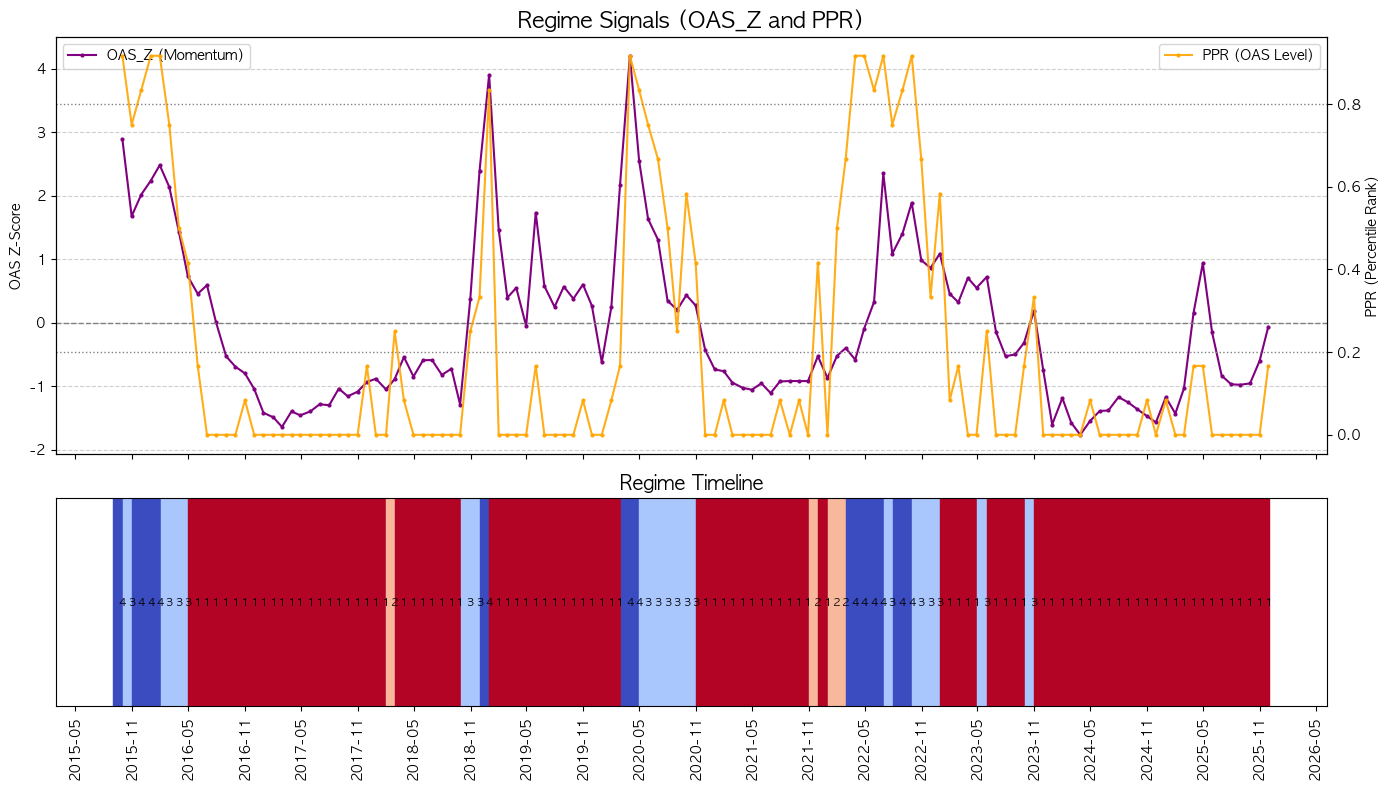

In [34]:
# %%
# =============================================================================
# [Cell 12] Step 6: 시각화 (2) - (!! 'heatmap' 대신 'axvspan' 수동 구현 !!)
# =============================================================================
import matplotlib.dates as mdates
import matplotlib.colors as mcolors

# [Cell 8]에서 생성된 'strategy_returns'가 필요합니다.
if 'strategy_returns' not in locals():
    print("오류: [Cell 8]을 먼저 실행하여 'strategy_returns'를 생성해야 합니다.")
else:
    plot_signals = signals.loc[strategy_returns.index].copy()
    plot_regime = regime_series.loc[strategy_returns.index].copy()

    print("\n--- [Cell 12] 'plot_signals' 데이터 확인 (Head) ---")
    print(plot_signals.head())

    fig, (ax1, ax2) = plt.subplots(
        2, 1, 
        figsize=(14, 8), 
        sharex=True,  # x축 공유 (이것이 중요)
        gridspec_kw={'height_ratios': [2, 1]} # 상단 그래프를 더 크게
    )

    # =====================================================================
    # [수정 1] 상단 라인 그래프 (ax1)
    # x축을 'datetime'으로 먼저 확정시킵니다.
    # =====================================================================
    ax1.plot(plot_signals.index, plot_signals['OAS_Z'], 
             label='OAS_Z (Momentum)', color='purple', marker='.', markersize=4)
    ax1.axhline(0, color='grey', linestyle='--', linewidth=1)
    ax1.set_ylabel('OAS Z-Score')
    ax1.legend(loc='upper left')
    ax1.grid(True, axis='y', linestyle='--', alpha=0.6) # Y축 그리드 추가

    ax_ppr = ax1.twinx()
    ax_ppr.plot(plot_signals.index, plot_signals['PPR'], 
                label='PPR (OAS Level)', color='orange', alpha=0.9, marker='.', markersize=4)
    ax_ppr.axhline(0.2, color='grey', linestyle=':', linewidth=1)
    ax_ppr.axhline(0.8, color='grey', linestyle=':', linewidth=1)
    ax_ppr.set_ylabel('PPR (Percentile Rank)')
    ax_ppr.legend(loc='upper right')
    ax1.set_title('Regime Signals (OAS_Z and PPR)', fontsize=16)

    # =====================================================================
    # [수정 2] 하단 레짐 타임라인 (ax2) - seaborn.heatmap 대체
    # =====================================================================

    # 1. 색상 맵과 노멀라이저 정의 (1, 2, 3, 4 레짐)
    cmap = plt.get_cmap('coolwarm_r', 4) # 4개의 불연속 색상
    norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

    # 2. axvspan (수직 음영)으로 수동 'heatmap' 구현
    for i in range(len(plot_regime)):
        regime = plot_regime.iloc[i]
        date_center = plot_regime.index[i]
        
        # 월의 시작일과 마지막일 계산 (정확한 칸을 위해)
        date_start = date_center.to_period('M').start_time
        date_end = date_center.to_period('M').end_time
        
        # 레짐 값에 맞는 색상 선택
        color = cmap(norm(regime))
        
        # 해당 월의 영역에 색 칠하기
        ax2.axvspan(date_start, date_end, color=color, ymin=0, ymax=1)
        
        # 해당 월의 중앙에 레짐 숫자(텍스트) 표시
        ax2.text(date_center, 0.5, f"{int(regime)}", 
                 ha='center', va='center', color='black', fontsize=8)

    ax2.set_title('Regime Timeline', fontsize=14)
    ax2.set_yticks([]) # Y축 눈금 제거
    ax2.set_ylim(0, 1) # Y축 범위 고정

    # =====================================================================
    # [수정 3] X축 날짜 포맷팅
    # =====================================================================
    
    # x축 레이블을 'YYYY-MM' 형식으로
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    # x축 레이블을 6개월마다 표시
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    
    # x축 레이블 90도 회전
    plt.setp(ax2.get_xticklabels(), rotation=90, ha="center")
    
    # 그래프 사이의 간격 조절
    plt.tight_layout()
    plt.show()

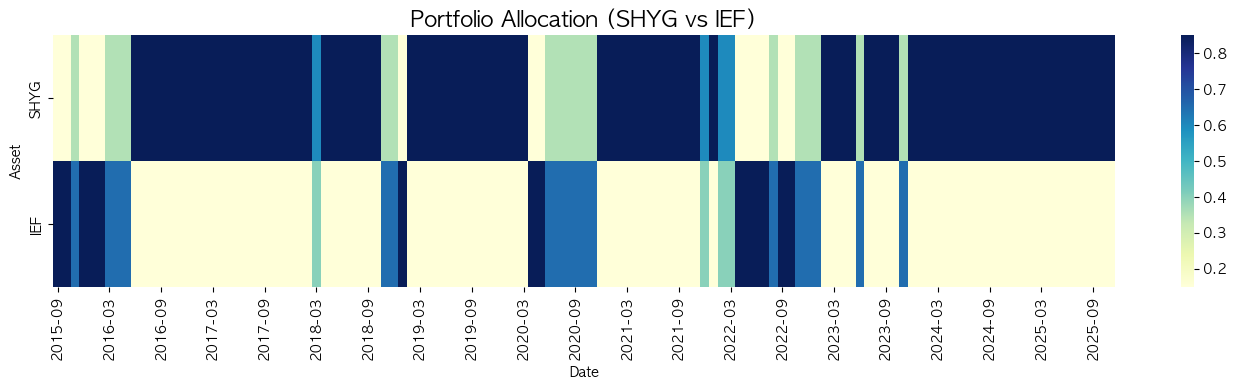

In [35]:
# %%
# =============================================================================
# [Cell 13] Step 6: 시각화 (3) - (!! IndexError 수정 !!)
# =============================================================================

if 'strategy_weights' not in locals():
    print("오류: [Cell 8]을 먼저 실행하여 'strategy_weights'를 생성해야 합니다.")
else:
    plt.figure(figsize=(14, 4))
    
    # 1. 히트맵을 그리고, matplotlib의 'axis' 객체(ax)를 받아옵니다.
    ax = sns.heatmap(strategy_weights.T, cmap='YlGnBu', annot=False, cbar=True)
    
    plt.title('Portfolio Allocation (SHYG vs IEF)', fontsize=16)
    plt.xlabel('Date')
    plt.ylabel('Asset')
    
    # =====================================================================
    # [수정] X축 레이블 포맷팅 (IndexError 해결)
    # =====================================================================
    
    # 2. x축의 원본 날짜 데이터(strategy_weights.T.columns)를 가져옵니다.
    date_labels = strategy_weights.T.columns
    N = 6 # 6개월(N=6)에 한 번씩만 레이블 표시
    
    new_ticks = []
    new_labels = []

    # 3. 원본 날짜 데이터를 기준으로 N번째마다 tick 위치와 포맷팅된 라벨을 저장합니다.
    # (수정) ax.get_xticks()를 신뢰하지 않고, 'i + 0.5'로 위치를 직접 계산합니다.
    for i, date in enumerate(date_labels):
        if i % N == 0:
            # heatmap의 틱은 0.5, 1.5, 2.5 ... 에 위치합니다.
            new_ticks.append(i + 0.5) 
            
            # 해당 날짜를 'YYYY-MM' 형식으로 변환
            new_labels.append(date.strftime('%Y-%m'))
    
    # 4. x축의 tick과 label을 새로 설정합니다.
    ax.set_xticks(new_ticks)
    ax.set_xticklabels(new_labels, rotation=90)

    plt.tight_layout()
    plt.show() # 바로 확인

In [36]:
# %%
# =============================================================================
# [Cell 14] 섹션 5: Fama-French 채권 2-팩터 생성
# =============================================================================
# (회귀분석을 위해 statsmodels 임포트)
import statsmodels.api as sm 

# [Cell 4]에서 로드한 'all_monthly_returns'와 [Cell 9]의 'strategy_returns'가 필요합니다.
# (참고: factor 계산을 위해 'all_monthly_returns'를 사용해야 날짜가 맞습니다)
if 'all_monthly_returns' not in locals() or 'strategy_returns' not in locals():
    print("오류: [Cell 4]와 [Cell 9]를 먼저 실행하여 'all_monthly_returns'와 'strategy_returns'를 생성해야 합니다.")
else:
    # 1. 팩터 생성에 필요한 월별 수익률 데이터 복사
    factor_data = all_monthly_returns[['SHY', 'IEF', 'SHYG', 'AGG']].copy()
    
    # 2. 무위험 수익률 (Risk-Free, RF) 정의
    # (단기 국채인 SHY의 수익률을 RF 프록시로 사용)
    factor_data['RF'] = factor_data['SHY']
    
    # 3. Fama-French (1993) 채권 2-팩터 생성
    
    # TERM 팩터 (듀레이션 리스크): 중기 국채 초과수익률 (IEF - RF)
    factor_data['TERM_Factor'] = factor_data['IEF'] - factor_data['RF']
    
    # CREDIT 팩터 (신용 리스크): 하이일드 - (듀레이션이 유사한) 국채 (SHYG - IEF)
    factor_data['CREDIT_Factor'] = factor_data['SHYG'] - factor_data['IEF']
    
    # 4. 종속 변수(Y) 생성: 전략과 벤치마크의 '초과 수익률'
    
    # 전략의 초과수익률 (Y1)
    y_strategy = (strategy_returns - factor_data['RF']).rename('Strategy_Excess_Return')
    
    # 벤치마크(AGG)의 초과수익률 (Y2)
    y_benchmark = (factor_data['AGG'] - factor_data['RF']).rename('Benchmark_Excess_Return')
    
    # 5. 회귀분석용 데이터셋 준비 (X, Y)
    
    # X (독립변수: 2-팩터)
    # .add_constant()는 회귀식의 절편(alpha)을 추가합니다.
    X_factors = sm.add_constant(factor_data[['TERM_Factor', 'CREDIT_Factor']])

    # Y (종속변수: 초과수익률)
    Y_data = pd.concat([y_strategy, y_benchmark], axis=1)
    
    # 6. X와 Y의 날짜 인덱스 정렬 및 NaN 제거 (백테스트 시작 시점)
    regression_data = pd.concat([Y_data, X_factors], axis=1).dropna()
    
    # 7. 최종 회귀분석용 데이터 분리
    Y_strategy_final = regression_data['Strategy_Excess_Return']
    Y_benchmark_final = regression_data['Benchmark_Excess_Return']
    X_final = regression_data[['const', 'TERM_Factor', 'CREDIT_Factor']]

    print("--- [확인] 회귀분석용 팩터 데이터 (Head) ---")
    print(X_final.head())
    
    print("\n--- [확인] 회귀분석용 Y 데이터 (Head) ---")
    print(Y_strategy_final.head())

--- [확인] 회귀분석용 팩터 데이터 (Head) ---
            const  TERM_Factor  CREDIT_Factor
2015-10-30    1.0    -0.004956       0.030423
2015-11-30    1.0    -0.001693      -0.013848
2015-12-31    1.0    -0.003040      -0.010431
2016-01-29    1.0     0.026818      -0.044341
2016-02-29    1.0     0.013739      -0.001650

--- [확인] 회귀분석용 Y 데이터 (Head) ---
2015-10-30   -0.000393
2015-11-30   -0.007440
2015-12-31   -0.005504
2016-01-29    0.020167
2016-02-29    0.013492
Freq: BME, Name: Strategy_Excess_Return, dtype: float64


In [23]:
# %%
# =============================================================================
# [Cell 15] 섹션 6: (1) "나의 전략" 팩터 회귀분석 실행
# =============================================================================
# (이전 노트북 [Cell 18]에 해당)

if 'Y_strategy_final' in locals() and 'X_final' in locals():
    model_strategy = sm.OLS(Y_strategy_final, X_final).fit()
    
    print("\n" + "="*50)
    print("      <<< 나의 전략 (Strategy) - 팩터 회귀분석 결과 >>>")
    print("="*50)
    print(model_strategy.summary())
else:
    print("오류: [Cell 14]를 먼저 실행해주세요.")


      <<< 나의 전략 (Strategy) - 팩터 회귀분석 결과 >>>
                              OLS Regression Results                              
Dep. Variable:     Strategy_Excess_Return   R-squared:                       0.755
Model:                                OLS   Adj. R-squared:                  0.750
Method:                     Least Squares   F-statistic:                     178.4
Date:                    Mon, 17 Nov 2025   Prob (F-statistic):           4.09e-36
Time:                            16:59:48   Log-Likelihood:                 430.11
No. Observations:                     119   AIC:                            -854.2
Df Residuals:                         116   BIC:                            -845.9
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

In [24]:
# %%
# =============================================================================
# [Cell 16] 섹션 6: (2) "벤치마크 (AGG)" 팩터 회귀분석 실행
# =============================================================================
# (이전 노트북 [Cell 18]에 해당 - 노트북 셀이 잘못 병합되어 있었습니다)

if 'Y_benchmark_final' in locals() and 'X_final' in locals():
    model_benchmark = sm.OLS(Y_benchmark_final, X_final).fit()
    
    print("\n" + "="*50)
    print("      <<< 벤치마크 (AGG) - 팩터 회귀분석 결과 >>>")
    print("="*50)
    print(model_benchmark.summary())
else:
    print("오류: [Cell 14]를 먼저 실행해주세요.")


      <<< 벤치마크 (AGG) - 팩터 회귀분석 결과 >>>
                               OLS Regression Results                              
Dep. Variable:     Benchmark_Excess_Return   R-squared:                       0.935
Model:                                 OLS   Adj. R-squared:                  0.934
Method:                      Least Squares   F-statistic:                     838.1
Date:                     Mon, 17 Nov 2025   Prob (F-statistic):           1.10e-69
Time:                             16:59:53   Log-Likelihood:                 526.75
No. Observations:                      119   AIC:                            -1048.
Df Residuals:                          116   BIC:                            -1039.
Df Model:                                2                                         
Covariance Type:                 nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

In [25]:
# %%
# =============================================================================
# [Cell 17] 섹션 7: 팩터 민감도(Beta) 및 T-stat 비교 요약 (!! NameError 수정 !!)
# =============================================================================
# (이전 노트북 [Cell 39]에 해당)

if 'model_strategy' in locals() and 'model_benchmark' in locals():
    # 1. 각 모델에서 베타(coef)와 t-stat(t) 추출
    results_strategy = pd.DataFrame({
        'Strategy_Beta': model_strategy.params,
        'Strategy_t-stat': model_strategy.tvalues
    })
    
    results_benchmark = pd.DataFrame({
        'Benchmark_Beta': model_benchmark.params,
        'Benchmark_t-stat': model_benchmark.tvalues
    })
    
    # 2. (!! 수정 !!) 두 결과를 'summary_table' 변수에 ★저장★합니다.
    summary_table = pd.concat([results_strategy, results_benchmark], axis=1)
    
    # 3. 소수점 정리 (화면 출력용)
    summary_table_formatted = summary_table.applymap(lambda x: f"{x:.4f}")
    
    print("\n" + "="*60)
    print("    <<< [최종 요약] 팩터 민감도 (Beta) 및 T-stat 비교 >>>")
    print("="*60)
    print(summary_table_formatted)

    print("\n--- [해석 가이드] ---")
    print("1. Beta (계수): 팩터에 대한 민감도(노출도)입니다.")
    print("   - const (alpha): 팩터로 설명되지 않는 '진짜 초과수익'입니다.")
    print("   - TERM_Factor Beta: 듀레이션(금리) 리스크에 대한 노출도입니다.")
    print("   - CREDIT_Factor Beta: 크레딧(신용) 리스크에 대한 노출도입니다.")
    print("\n2. t-stat (T-value):")
    print("   - |t| > 2 (절대값 2 이상)일 경우, 해당 베타(노출)가 통계적으로 유의미했음을 의미합니다.")

else:
    print("오류: [Cell 15], [Cell 16]을 먼저 실행해주세요.")


    <<< [최종 요약] 팩터 민감도 (Beta) 및 T-stat 비교 >>>
              Strategy_Beta Strategy_t-stat Benchmark_Beta Benchmark_t-stat
const               -0.0007         -1.1906        -0.0003          -1.2622
TERM_Factor          0.9021         16.8983         0.9192          38.7861
CREDIT_Factor        0.6267         17.5813         0.2570          16.2401

--- [해석 가이드] ---
1. Beta (계수): 팩터에 대한 민감도(노출도)입니다.
   - const (alpha): 팩터로 설명되지 않는 '진짜 초과수익'입니다.
   - TERM_Factor Beta: 듀레이션(금리) 리스크에 대한 노출도입니다.
   - CREDIT_Factor Beta: 크레딧(신용) 리스크에 대한 노출도입니다.

2. t-stat (T-value):
   - |t| > 2 (절대값 2 이상)일 경우, 해당 베타(노출)가 통계적으로 유의미했음을 의미합니다.


In [20]:
# %%
# =============================================================================
# [Cell 19] (신규) 섹션 8: 롤링 팩터 회귀분석 (시간대별 노출도)
# =============================================================================
from statsmodels.regression.rolling import RollingOLS

# 회귀분석 윈도우 (36개월 = 3년)
ROLLING_WINDOW = 36

# [Cell 14]에서 생성한 'regression_data' 변수가 필요합니다.
if 'regression_data' not in locals():
    print("오류: [Cell 14]를 먼저 실행하여 'regression_data'를 생성해야 합니다.")
else:
    print(f"시간대별 팩터 노출도(Rolling Beta)를 {ROLLING_WINDOW}개월 윈도우로 계산합니다...")
    
    # 1. Y (종속변수: 전략의 초과 수익률)
    endog = regression_data['Strategy_Excess_Return']
    
    # 2. X (독립변수: 상수, TERM, CREDIT 팩터)
    exog = regression_data[['const', 'TERM_Factor', 'CREDIT_Factor']]
    
    # 3. 롤링 OLS 모델 설정
    # (min_nobs=ROLLING_WINDOW를 설정하여 최소 기간이 차야 계산 시작)
    model_rolling = RollingOLS(endog, exog, window=ROLLING_WINDOW, min_nobs=ROLLING_WINDOW)
    
    # 4. 모델 피팅
    rolling_results = model_rolling.fit()
    
    # 5. 시간대별 베타(계수) 추출 및 NaN 제거
    rolling_betas = rolling_results.params.dropna()
    
    print("\n--- [확인] 롤링 베타 (Head) ---")
    print(rolling_betas.head())
    
    print("\n--- [확인] 롤링 베타 (Tail) ---")
    print(rolling_betas.tail())

시간대별 팩터 노출도(Rolling Beta)를 36개월 윈도우로 계산합니다...

--- [확인] 롤링 베타 (Head) ---
               const  TERM_Factor  CREDIT_Factor
2018-09-28  0.002720     0.559135       0.303644
2018-10-31  0.002081     0.740689       0.463744
2018-11-30  0.002195     0.721518       0.447895
2018-12-31  0.002744     0.647783       0.366030
2019-01-31  0.002055     0.534025       0.360640

--- [확인] 롤링 베타 (Tail) ---
               const  TERM_Factor  CREDIT_Factor
2025-04-30  0.000271     0.804413       0.365742
2025-05-30  0.000477     0.816553       0.395901
2025-06-30 -0.000371     0.891599       0.513589
2025-07-31 -0.000324     0.920715       0.546335
2025-08-29 -0.000125     0.890573       0.524392


In [26]:
# %%
# =============================================================================
# [Cell 18] (확인) 요약 테이블 변수 확인
# =============================================================================
# (이전 노트북 [Cell 41]에 해당 - 이제 에러 없이 실행되어야 합니다)
# (소수점 정리 안 된 원본 데이터를 확인합니다)
summary_table

,Strategy_Beta,Strategy_t-stat,Benchmark_Beta,Benchmark_t-stat
const,-0.000733,-1.190648,-0.000345,-1.262215
TERM_Factor,0.902134,16.898326,0.919160,38.786138
CREDIT_Factor,0.626656,17.581333,0.256953,16.240132


In [27]:
# %%
# =============================================================================
# [Cell 19] (신규) 섹션 8: 롤링 팩터 회귀분석 (시간대별 노출도)
# =============================================================================
# (이전 노트북 [Cell 20]에 해당)
from statsmodels.regression.rolling import RollingOLS

# 회귀분석 윈도우 (36개월 = 3년)
ROLLING_WINDOW = 36

# [Cell 14]에서 생성한 'regression_data' 변수가 필요합니다.
if 'regression_data' not in locals():
    print("오류: [Cell 14]를 먼저 실행하여 'regression_data'를 생성해야 합니다.")
else:
    print(f"시간대별 팩터 노출도(Rolling Beta)를 {ROLLING_WINDOW}개월 윈도우로 계산합니다...")
    
    # 1. Y (종속변수: 전략의 초과 수익률)
    endog = regression_data['Strategy_Excess_Return']
    
    # 2. X (독립변수: 상수, TERM, CREDIT 팩터)
    exog = regression_data[['const', 'TERM_Factor', 'CREDIT_Factor']]
    
    # 3. 롤링 OLS 모델 설정
    # (min_nobs=ROLLING_WINDOW를 설정하여 최소 기간이 차야 계산 시작)
    model_rolling = RollingOLS(endog, exog, window=ROLLING_WINDOW, min_nobs=ROLLING_WINDOW)
    
    # 4. 모델 피팅
    rolling_results = model_rolling.fit()
    
    # 5. 시간대별 베타(계수) 추출 및 NaN 제거
    rolling_betas = rolling_results.params.dropna()
    
    print("\n--- [확인] 롤링 베타 (Head) ---")
    print(rolling_betas.head())
    
    print("\n--- [확인] 롤링 베타 (Tail) ---")
    print(rolling_betas.tail())

시간대별 팩터 노출도(Rolling Beta)를 36개월 윈도우로 계산합니다...

--- [확인] 롤링 베타 (Head) ---
               const  TERM_Factor  CREDIT_Factor
2018-09-28  0.002720     0.559135       0.303644
2018-10-31  0.002081     0.740689       0.463744
2018-11-30  0.002195     0.721518       0.447895
2018-12-31  0.002744     0.647783       0.366030
2019-01-31  0.002055     0.534025       0.360640

--- [확인] 롤링 베타 (Tail) ---
               const  TERM_Factor  CREDIT_Factor
2025-04-30  0.000271     0.804413       0.365742
2025-05-30  0.000477     0.816553       0.395901
2025-06-30 -0.000371     0.891599       0.513589
2025-07-31 -0.000324     0.920715       0.546335
2025-08-29 -0.000125     0.890573       0.524392


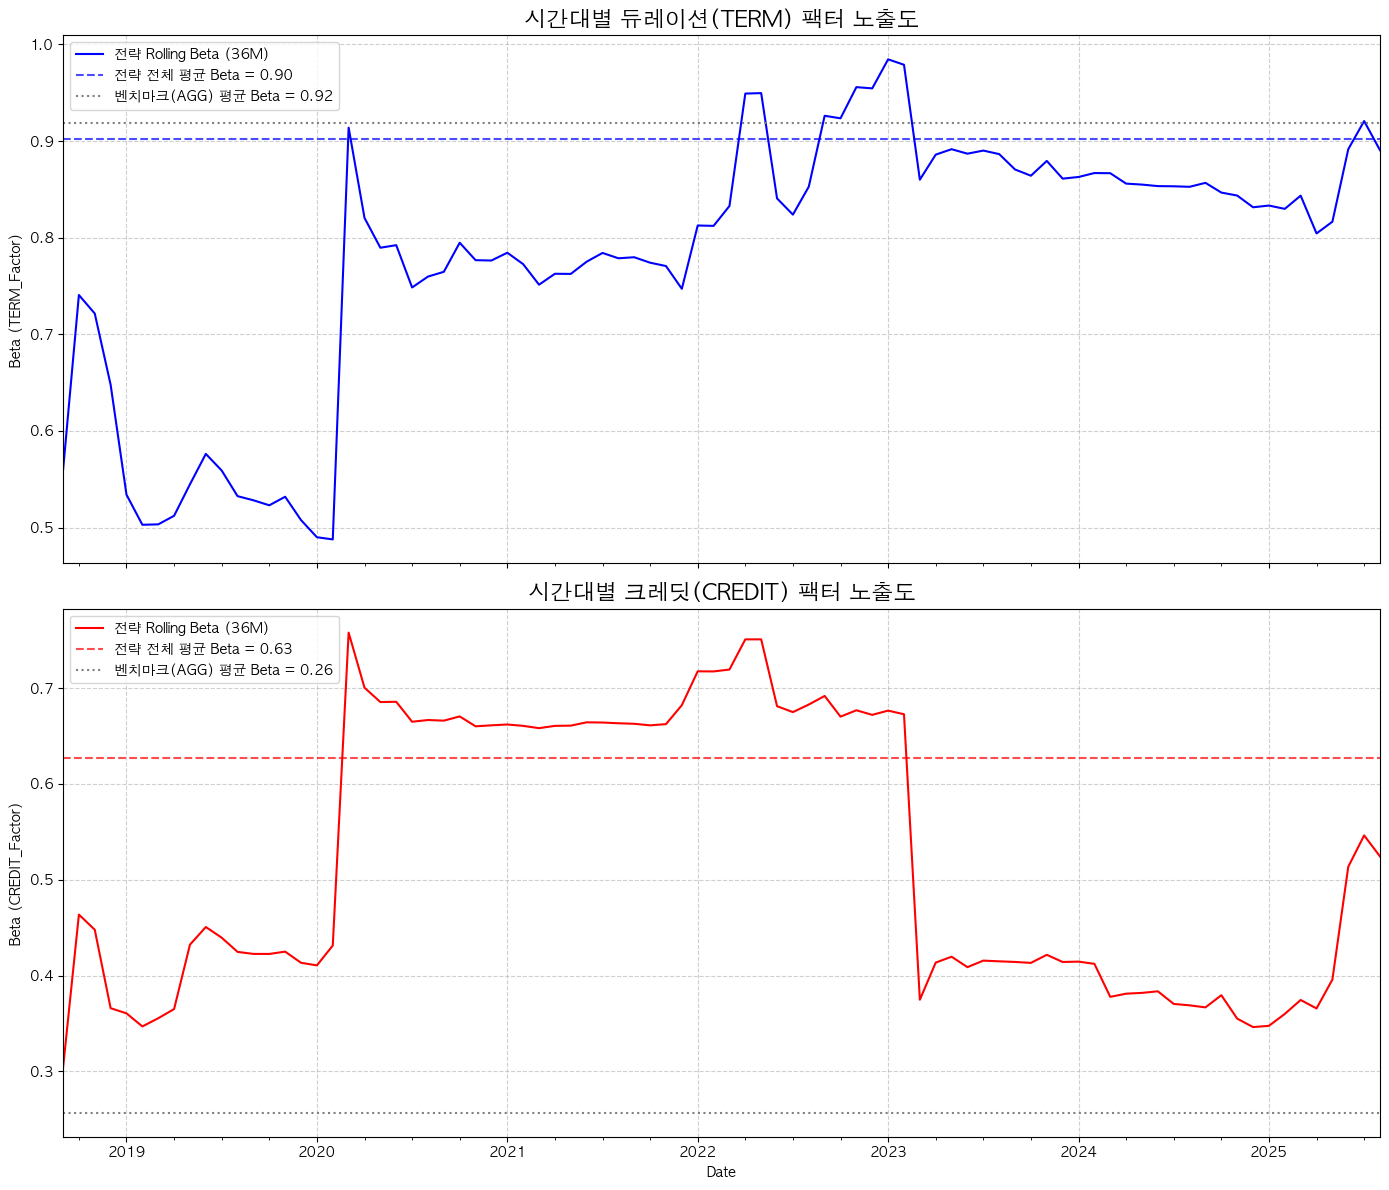

In [30]:
# %%
# =============================================================================
# [Cell 20] (신규) 섹션 8: 시각화 - 시간대별 팩터 노출도
# =============================================================================
# (이전 노트북 [Cell 21]에 해당)

# [Cell 17]의 'summary_table'과 [Cell 19]의 'rolling_betas'가 필요합니다.
if 'rolling_betas' in locals() and 'summary_table' in locals():
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
    
    # --- [비교 기준선] 전체 기간의 평균 베타 ---
    # 1. 전략 (수정안 3)의 전체 기간 평균 베타
    static_beta_term_strat = summary_table.loc['TERM_Factor', 'Strategy_Beta']
    static_beta_credit_strat = summary_table.loc['CREDIT_Factor', 'Strategy_Beta']

    # 2. 벤치마크 (AGG)의 전체 기간 평균 베타
    static_beta_term_agg = summary_table.loc['TERM_Factor', 'Benchmark_Beta']
    static_beta_credit_agg = summary_table.loc['CREDIT_Factor', 'Benchmark_Beta']

    # --- [그래프 1] 롤링 듀레이션(TERM) 팩터 노출도 ---
    rolling_betas['TERM_Factor'].plot(ax=ax1, 
                                      label=f'전략 Rolling Beta ({ROLLING_WINDOW}M)', 
                                      color='blue')
    ax1.axhline(static_beta_term_strat, 
                label=f'전략 전체 평균 Beta = {static_beta_term_strat:.2f}', 
                color='blue', linestyle='--', alpha=0.7)
    
    ax1.axhline(static_beta_term_agg, 
                label=f'벤치마크(AGG) 평균 Beta = {static_beta_term_agg:.2f}', 
                color='grey', linestyle=':')
    
    ax1.set_title('시간대별 듀레이션(TERM) 팩터 노출도', fontsize=16)
    ax1.set_ylabel('Beta (TERM_Factor)')
    ax1.legend(loc='upper left')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- [그래프 2] 롤링 크레딧(CREDIT) 팩터 노출도 ---
    rolling_betas['CREDIT_Factor'].plot(ax=ax2, 
                                        label=f'전략 Rolling Beta ({ROLLING_WINDOW}M)', 
                                        color='red')
    ax2.axhline(static_beta_credit_strat, 
                label=f'전략 전체 평균 Beta = {static_beta_credit_strat:.2f}', 
                color='red', linestyle='--', alpha=0.7)
    
    ax2.axhline(static_beta_credit_agg, 
                label=f'벤치마크(AGG) 평균 Beta = {static_beta_credit_agg:.2f}', 
                color='grey', linestyle=':')
    
    ax2.set_title('시간대별 크레딧(CREDIT) 팩터 노출도', fontsize=16)
    ax2.set_ylabel('Beta (CREDIT_Factor)')
    ax2.set_xlabel('Date')
    ax2.legend(loc='upper left')
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

else:
    print("오류: [Cell 17]과 [Cell 19]를 먼저 실행하여 'summary_table'과 'rolling_betas'를 생성해야 합니다.")

In [34]:
# %%
# =============================================================================
# [Cell 14] 섹션 5: Fama-French 채권 2-팩터 생성
# =============================================================================
# (회귀분석을 위해 statsmodels 임포트)
import statsmodels.api as sm 

# [Cell 4]에서 로드한 'all_monthly_returns'와 [Cell 9]의 'strategy_returns'가 필요합니다.
if 'all_monthly_returns' not in locals() or 'strategy_returns' not in locals():
    print("오류: [Cell 4]와 [Cell 9]를 먼저 실행하여 'all_monthly_returns'와 'strategy_returns'를 생성해야 합니다.")
else:
    # 1. 팩터 생성에 필요한 월별 수익률 데이터 복사
    factor_data = all_monthly_returns[['SHY', 'IEF', 'SHYG', 'AGG']].copy()
    
    # 2. 무위험 수익률 (Risk-Free, RF) 정의
    factor_data['RF'] = factor_data['SHY']
    
    # 3. Fama-French (1993) 채권 2-팩터 생성
    # TERM 팩터 (듀레이션 리스크): IEF - RF
    factor_data['TERM_Factor'] = factor_data['IEF'] - factor_data['RF']
    # CREDIT 팩터 (신용 리스크): SHYG - IEF
    factor_data['CREDIT_Factor'] = factor_data['SHYG'] - factor_data['IEF']
    
    # 4. 종속 변수(Y) 생성: 전략과 벤치마크의 '초과 수익률'
    y_strategy = (strategy_returns - factor_data['RF']).rename('Strategy_Excess_Return')
    y_benchmark = (factor_data['AGG'] - factor_data['RF']).rename('Benchmark_Excess_Return')
    
    # 5. 회귀분석용 데이터셋 준비 (X, Y)
    X_factors = sm.add_constant(factor_data[['TERM_Factor', 'CREDIT_Factor']])
    Y_data = pd.concat([y_strategy, y_benchmark], axis=1)
    
    # 6. X와 Y의 날짜 인덱스 정렬 및 NaN 제거
    regression_data = pd.concat([Y_data, X_factors], axis=1).dropna()
    
    # 7. 최종 회귀분석용 데이터 분리
    Y_strategy_final = regression_data['Strategy_Excess_Return']
    Y_benchmark_final = regression_data['Benchmark_Excess_Return']
    X_final = regression_data[['const', 'TERM_Factor', 'CREDIT_Factor']]

    print("--- [확인] 회귀분석용 팩터 데이터 (Head) ---")
    print(X_final.head())

--- [확인] 회귀분석용 팩터 데이터 (Head) ---
            const  TERM_Factor  CREDIT_Factor
2015-10-30    1.0    -0.004957       0.030423
2015-11-30    1.0    -0.001694      -0.013850
2015-12-31    1.0    -0.003039      -0.010430
2016-01-29    1.0     0.026817      -0.044341
2016-02-29    1.0     0.013740      -0.001649


In [35]:
# %%
# =============================================================================
# [Cell 15] 섹션 6: (1) "나의 전략" 팩터 회귀분석 실행
# =============================================================================

if 'Y_strategy_final' in locals() and 'X_final' in locals():
    model_strategy = sm.OLS(Y_strategy_final, X_final).fit()
    
    print("\n" + "="*50)
    print("      <<< 나의 전략 (Strategy) - 팩터 회귀분석 결과 >>>")
    print("="*50)
    print(model_strategy.summary())
else:
    print("오류: [Cell 14]를 먼저 실행해주세요.")


      <<< 나의 전략 (Strategy) - 팩터 회귀분석 결과 >>>
                              OLS Regression Results                              
Dep. Variable:     Strategy_Excess_Return   R-squared:                       0.755
Model:                                OLS   Adj. R-squared:                  0.750
Method:                     Least Squares   F-statistic:                     178.4
Date:                    Mon, 17 Nov 2025   Prob (F-statistic):           4.09e-36
Time:                            17:32:43   Log-Likelihood:                 430.11
No. Observations:                     119   AIC:                            -854.2
Df Residuals:                         116   BIC:                            -845.9
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

In [36]:
# %%
# =============================================================================
# [Cell 16] 섹션 6: (2) "벤치마크 (AGG)" 팩터 회귀분석 실행
# =============================================================================

if 'Y_benchmark_final' in locals() and 'X_final' in locals():
    model_benchmark = sm.OLS(Y_benchmark_final, X_final).fit()
    
    print("\n" + "="*50)
    print("      <<< 벤치마크 (AGG) - 팩터 회귀분석 결과 >>>")
    print("="*50)
    print(model_benchmark.summary())
else:
    print("오류: [Cell 14]를 먼저 실행해주세요.")


      <<< 벤치마크 (AGG) - 팩터 회귀분석 결과 >>>
                               OLS Regression Results                              
Dep. Variable:     Benchmark_Excess_Return   R-squared:                       0.935
Model:                                 OLS   Adj. R-squared:                  0.934
Method:                      Least Squares   F-statistic:                     838.1
Date:                     Mon, 17 Nov 2025   Prob (F-statistic):           1.10e-69
Time:                             17:32:49   Log-Likelihood:                 526.75
No. Observations:                      119   AIC:                            -1048.
Df Residuals:                          116   BIC:                            -1039.
Df Model:                                2                                         
Covariance Type:                 nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

In [37]:
# %%
# =============================================================================
# [Cell 18] (확인) 요약 테이블 변수 확인
# =============================================================================
# (이 셀을 실행하면 summary_table 변수의 내용을 직접 볼 수 있습니다.)
summary_table

,Strategy_Beta,Strategy_t-stat,Benchmark_Beta,Benchmark_t-stat
const,-0.000733,-1.190648,-0.000345,-1.262215
TERM_Factor,0.902134,16.898326,0.919160,38.786138
CREDIT_Factor,0.626656,17.581333,0.256953,16.240132


# snaphot확인

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from pandas.tseries.offsets import BMonthEnd
from scipy.stats import zscore
from fredapi import Fred
import datetime
import statsmodels.api as sm
import matplotlib.dates as mdates
import matplotlib.colors as mcolors


# (경고 메시지 무시)
import warnings
warnings.filterwarnings('ignore')

# --- [0] 글로벌 세팅 ---

# 백테스트 기간 (스냅샷 확인 시에는 사용되지 않음)
START_DATE = '2015-08-01'
END_DATE = '2025-08-31'

# 사용 ETF 및 벤치마크
TICKERS = ['SHYG', 'IEF', 'SHY', 'TLT', 'AGG']
BENCHMARK = 'AGG'

# 거래 비용 (편도)
TRANSACTION_COSTS = {
    'SHYG': 0.003,  # 0.3%
    'IEF': 0.0015,  # 0.15%
    'SHY': 0.0015,
    'TLT': 0.0015,
    'AGG': 0.0015,
}

# [수정안 3] 레짐별 타깃 포트폴리오 (TLT 미포함)
REGIME_ALLOCATIONS = {
    # 1: Very Risk-On (크레딧 위험 가장 낮음)
    1: {'SHYG': 0.85, 'IEF': 0.15}, 
    
    # 2: Risk-On (스프레드 축소 모멘텀)
    2: {'SHYG': 0.60, 'IEF': 0.40}, 
    
    # 3: Risk-Off (스프레드 확대 모멘텀)
    3: {'SHYG': 0.35, 'IEF': 0.65}, 
    
    # 4: Very Risk-Off (시장 공포)
    4: {'SHYG': 0.15, 'IEF': 0.85}, 
}

# FRED API 키
FRED_API_KEY = 'f75d683dda2053416b64caae44e1bfb2' 

# 롤링 윈도우 설정
OAS_Z_WINDOW = 24  # 24개월 (모멘텀)
PPR_WINDOW = 12    # 12개월 (ELP Proxy)

print("셀 1: 기본 세팅 완료 (수정안 3 - TLT 미포함)")

셀 1: 기본 세팅 완료 (수정안 3 - TLT 미포함)


In [4]:
def load_data(tickers, start, end):
    """yfinance에서 수정종가(Adj Close) 데이터를 로드 (월말 기준)"""
    print(f"Step: yfinance 데이터 로딩 중... (Start: {start})")
    try:
        data = yf.download(tickers, start=start, end=end)['Close']
        if isinstance(data.columns, str):
            data = data.to_frame(tickers[0])
        monthly_prices = data.resample('BM').last()
        monthly_returns = monthly_prices.pct_change().dropna()
        print("yfinance 데이터 로딩 및 월별 전처리 완료.")
        return monthly_prices, monthly_returns
    except Exception as e:
        print(f"yfinance 데이터 로드 오류: {e}")
        return None, None

def load_external_data(fred_api_key, series_id, end_date):
    """
    FRED API를 통해 OAS 데이터를 로드 (롤링 윈도우를 위해 넉넉하게 불러옴)
    """
    print(f"Step: FRED API에서 {series_id} 로딩 중...")
    try:
        fred = Fred(api_key=fred_api_key)
        
        # 롤링 윈도우(OAS_Z_WINDOW) 계산을 위해 5년 전 데이터부터 로드
        fetch_start_date = (pd.to_datetime(end_date) - pd.DateOffset(years=5)).strftime('%Y-%m-%d')
        
        oas_series = fred.get_series(series_id, start_date=fetch_start_date, end_date=end_date)
        
        if oas_series.empty:
            print(f"오류: FRED에서 {series_id} 데이터를 가져오지 못했습니다.")
            return None

        # 월말(BM) 기준으로 리샘플링
        oas_series = oas_series.resample('BM').last().ffill()
        oas_series.name = 'OAS'
        
        print("OAS 데이터 로딩 및 월별 전처리 완료.")
        return oas_series
    
    except Exception as e:
        print(f"FRED API 오류: {e}")
        return None

print("셀 2: 데이터 로딩 함수 정의 완료.")

셀 2: 데이터 로딩 함수 정의 완료.


In [5]:
# --- [2] 성과 지표 함수 (원본 Cell 3) ---
def calculate_cagr(returns_series, periods_per_year=12):
    if len(returns_series) < 1: return np.nan
    total_return = (1 + returns_series).prod()
    num_years = len(returns_series) / periods_per_year
    return total_return ** (1 / num_years) - 1

def calculate_mdd(returns_series):
    cumulative_returns = (1 + returns_series).cumprod()
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns - peak) / peak
    return drawdown.min()

def calculate_sharpe_ratio(returns_series, risk_free_rate=0.0, periods_per_year=12):
    excess_returns = returns_series - (risk_free_rate / periods_per_year)
    mean_excess_return = excess_returns.mean()
    std_dev = excess_returns.std()
    if std_dev == 0: return np.nan
    return (mean_excess_return / std_dev) * np.sqrt(periods_per_year)

def generate_performance_summary(returns_series, benchmark_returns):
    summary = {}
    summary['Strategy'] = {
        'CAGR': calculate_cagr(returns_series),
        'MDD': calculate_mdd(returns_series),
        'Sharpe Ratio': calculate_sharpe_ratio(returns_series)
    }
    summary['Benchmark (AGG)'] = {
        'CAGR': calculate_cagr(benchmark_returns),
        'MDD': calculate_mdd(benchmark_returns),
        'Sharpe Ratio': calculate_sharpe_ratio(benchmark_returns)
    }
    summary_df = pd.DataFrame(summary).T
    return summary_df.applymap(lambda x: f"{x:.2%}" if x > -1 else f"{x:.2f}")

# --- [3] Regime 분류 함수 (원본 Cell 3 + [Cell 6] 수정) ---

def calculate_regime_signals(oas_series, shyg_price_series, oas_z_window, elp_window):
    """
    (수정됨: ValueError 해결)
    1. OAS 모멘텀 (OAS_Z) 계산
    2. SHYG 가격 기반 ELP_proxy (PPR로 사용) 계산
    """
    print(f"Step 3: 레짐 시그널 계산 중 (SHYG Price ELP_proxy {elp_window}M Window)...")
    
    # 1. OAS_Z (OAS 모멘텀)
    oas_z = oas_series.rolling(window=oas_z_window).apply(
        lambda x: (x[-1] - x.mean()) / x.std() if len(x) == oas_z_window else np.nan,
        raw=False
    )
    
    # 2. ELP_proxy (PPR 대체)
    percentile_rank = shyg_price_series.rolling(window=elp_window).rank(pct=True)
    elp_proxy = 1.0 - percentile_rank

    # [오류 수정] np.squeeze()를 사용하여 (N, 1) 형태의 배열을 (N,) 형태로 강제 변환
    signals = pd.DataFrame({
        'OAS_Z': np.squeeze(oas_z), 
        'PPR': np.squeeze(elp_proxy)
    })
    
    signals = signals.dropna()
    
    print("레짐 시그널 (OAS_Z + ELP_proxy as PPR) 생성 완료.")
    return signals

def define_regime(row):
    ppr, oas_z = row['PPR'], row['OAS_Z']
    if ppr < 0.2: return 1 # ① Very Risk-On
    if ppr > 0.8: return 4 # ④ Very Risk-Off
    if 0.2 <= ppr <= 0.8 and oas_z < 0: return 2 # ② Risk-On
    if 0.2 <= ppr <= 0.8 and oas_z >= 0: return 3 # ③ Risk-Off
    return np.nan

def generate_regime_timeseries(signals):
    regime_series = signals.apply(define_regime, axis=1)
    regime_series.name = 'Regime'
    return regime_series

# --- [4] 전략 구성 함수 (원본 Cell 3) ---
def get_target_weights(regime_series):
    # (수정안 3을 위해 'SHYG', 'IEF' 2개 자산만 사용)
    print("Step 4: 타깃 비중 생성 중... (수정안 3: SHYG, IEF)")
    target_weights = pd.DataFrame(index=regime_series.index, columns=['SHYG', 'IEF'])
    for regime, alloc in REGIME_ALLOCATIONS.items():
        mask = (regime_series == regime)
        target_weights.loc[mask] = [alloc['SHYG'], alloc['IEF']]
    target_weights = target_weights.ffill().dropna()
    return target_weights

# (이외 백테스트 및 스트레스 테스트 함수는 스냅샷 확인에 불필요하여 생략)

print("셀 3: 헬퍼 함수 정의 완료 (ValueError 수정 적용).")

셀 3: 헬퍼 함수 정의 완료 (ValueError 수정 적용).


In [ ]:
# --- 1. 스냅샷 기준 날짜 설정 ---
END_DATE_SNAPSHOT = datetime.date.today()
OAS_START_DATE_SNAPSHOT = END_DATE_SNAPSHOT - pd.DateOffset(years=5)
SHYG_START_DATE_SNAPSHOT = END_DATE_SNAPSHOT - pd.DateOffset(years=3)

# --- 2. FRED (OAS) 데이터 로드 ---
try:
    fred = Fred(api_key=FRED_API_KEY)
    oas_series_raw = fred.get_series('BAMLH0A0HYM2', start_date=OAS_START_DATE_SNAPSHOT, end_date=END_DATE_SNAPSHOT)
    oas_series_bm = oas_series_raw.resample('BM').last().ffill()
    print("FR ED (OAS) 데이터 로드 완료.")
    print("OAS 최신 데이터:\n", oas_series_bm.tail(3))
except Exception as e:
    print(f"FRED API 오류: {e}")

# --- 3. yfinance (SHYG Price) 데이터 로드 ---
try:
    data = yf.download('SHYG', start=SHYG_START_DATE_SNAPSHOT, end=END_DATE_SNAPSHOT)['Close']
    shyg_prices_raw = data.resample('BM').last().ffill()
    print("\nyfinance (SHYG) 데이터 로드 완료.")
    print("SHYG 최신 데이터:\n", shyg_prices_raw.tail(3))
except Exception as e:
    print(f"yfinance 데이터 로드 오류: {e}")

[*********************100%***********************]  1 of 1 completed

FRED (OAS) 데이터 로드 완료.
OAS 최신 데이터:
 2025-09-30    2.80
2025-10-31    2.94
2025-11-28    3.09
Freq: BME, dtype: float64

yfinance (SHYG) 데이터 로드 완료.
SHYG 최신 데이터:
 Ticker           SHYG
Date                 
2025-09-30  42.811153
2025-10-31  42.839001
2025-11-28  42.730000


In [13]:
# --- 1. 시그널 및 레짐 계산 ---
# (OAS_Z_WINDOW=24, PPR_WINDOW_NEW=12 설정값 사용)
signals_raw = calculate_regime_signals(
    oas_series_bm,       
    shyg_prices_raw,      
    OAS_Z_WINDOW,         
    PPR_WINDOW_NEW
)

signals_raw['Regime'] = generate_regime_timeseries(signals_raw)

# --- 2. 최종 결과 확인 ---
print("\n--- [확인] 계산된 최신 시그널 및 레짐 ---")
print(signals_raw.tail(5))

Step 3: 레짐 시그널 계산 중 (SHYG Price ELP_proxy 12M Window)...
레짐 시그널 (OAS_Z + ELP_proxy as PPR) 생성 완료.

--- [확인] 계산된 최신 시그널 및 레짐 ---
               OAS_Z       PPR  Regime
2025-07-31 -0.972959  0.000000       1
2025-08-29 -0.979346  0.000000       1
2025-09-30 -0.958649  0.000000       1
2025-10-31 -0.603399  0.000000       1
2025-11-28 -0.068209  0.166667       1


In [14]:
# --- 최신 스냅샷 확인 ---
if not signals_raw.empty:
    latest_snapshot = signals_raw.iloc[-1]
    latest_date = latest_snapshot.name
    latest_regime = int(latest_snapshot['Regime'])
    
    # [Cell 1]에서 정의한 REGIME_ALLOCATIONS (수정안 3) 사용
    target_allocation = REGIME_ALLOCATIONS[latest_regime]

    print("\n" + "="*40)
    print(f"      최신 스냅샷 (수정안 3)      ")
    print("="*40)
    print(f"데이터 기준일: {latest_date.strftime('%Y-%m-%d')}")
    print("-" * 40)
    print(f"PPR (레벨) 시그널: {latest_snapshot['PPR']:.4f}")
    print(f"OAS_Z (모멘텀) 시그널: {latest_snapshot['OAS_Z']:.4f}")
    print(f"-> 현재 레짐: {latest_regime}")
    print("\n" + "--- 목표 포트폴리오 비중 ---")
    print(f"SHYG: {target_allocation['SHYG']:.0%}")
    print(f"IEF:  {target_allocation['IEF']:.0%}")
else:
    print("시그널을 계산하기에 데이터가 충분하지 않습니다.")


      최신 스냅샷 (수정안 3)      
데이터 기준일: 2025-11-28
----------------------------------------
PPR (레벨) 시그널: 0.1667
OAS_Z (모멘텀) 시그널: -0.0682
-> 현재 레짐: 1

--- 목표 포트폴리오 비중 ---
SHYG: 85%
IEF:  15%


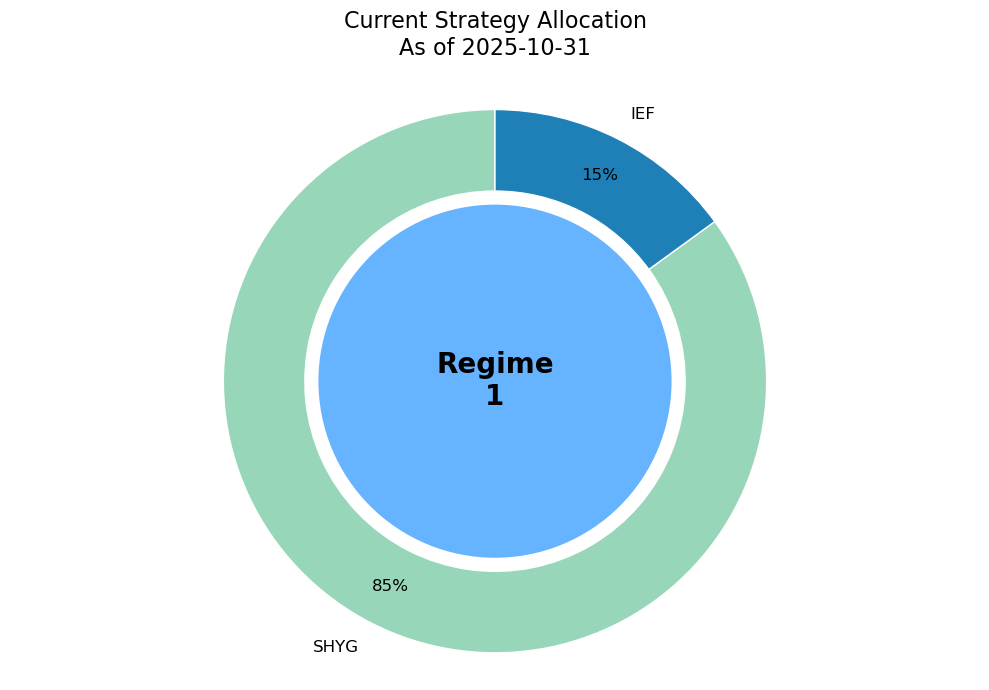

In [17]:
if 'target_allocation' in locals():
    labels = list(target_allocation.keys())
    sizes = list(target_allocation.values())
    
    # 레짐별 색상 정의 (시각적 일관성)
    regime_colors = {
        1: '#66b3ff', # 파란색 (Risk-On)
        2: '#99ff99', # 연두색 (Risk-On)
        3: '#ffcc99', # 주황색 (Risk-Off)
        4: '#ff9999'  # 붉은색 (Very Risk-Off)
    }
    
    # 자산별 색상 정의 (YlGnBu 팔레트 사용)
    asset_colors = sns.color_palette('YlGnBu', len(labels))
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # 바깥쪽 링 (자산 배분)
    ax.pie(sizes, 
           labels=labels, 
           autopct='%1.0f%%', 
           startangle=90, 
           colors=asset_colors, 
           pctdistance=0.85, 
           wedgeprops=dict(width=0.3, edgecolor='w'),
           textprops={'fontsize': 12})
    
    # 안쪽 원 (레짐 표시)
    centre_circle = plt.Circle((0,0), 0.65, fc=regime_colors.get(latest_regime, 'grey'))
    fig.gca().add_artist(centre_circle)
    
    # 레짐 텍스트
    plt.text(0, 0, 
             f'Regime\n{int(latest_regime)}', 
             ha='center', 
             va='center', 
             fontsize=20, 
             fontweight='bold')
    
    ax.set_title(f'Current Strategy Allocation\nAs of 2025-10-31', 
                 fontsize=16, 
                 pad=20)
    
    ax.axis('equal')
    plt.tight_layout()
    
    # 파일로 저장 및 출력
    # plt.savefig('snapshot_visualization.png')
    # print("\n시각화 차트가 'snapshot_visualization.png'로 저장되었습니다.")
    plt.show()

else:
    print("시각화를 위해 [Cell 6]을 먼저 실행하여 'target_allocation'을 생성해야 합니다.")